# Sumativa 3 — MCDI501: Estadística Computacional para la Toma de Decisiones
## Cierre y comunicación del proyecto — Fase 4

**Integrantes:** «Daniel Hormazábal», «Cristian Pastén»<br>
**Docente:** «Jean Paul Maidana»<br>
**Fecha:** «14/07/2026»

Semilla utilizada para reproducibilidad: `123456`

Este notebook integra el trabajo de S1 (análisis exploratorio e inferencial) y S2 (validación mediante remuestreo y simulación) para construir modelos de regresión lineal (imputación) y regresión logística (clasificación), siguiendo la progresión S1 → S2 → S3 solicitada en el enunciado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_SEED = 123456
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams.update({'font.size': 10})

## Parte 1 — Manejo inteligente de datos faltantes

### 1.1 Referencia al análisis de datos faltantes de la Sumativa 1

En S1 se verificó la ausencia de valores nulos estándar (`NaN`) en las 4.424 filas y 37 variables del dataset ("Predict Students' Dropout and Academic Success", Realinho et al., 2021). Sin embargo, ese chequeo estándar no detecta **faltantes disfrazados como códigos categóricos válidos**, un patrón documentado en el codebook oficial del dataset (UCI/Zenodo DOI: 10.5281/zenodo.5777340).

Se revisó el codebook completo y se identificaron dos categorías explícitas de faltante disfrazado:
- `Mother's occupation` / `Father's occupation`: código **99 = "(blank)"**
- `Mother's qualification` / `Father's qualification`: código **34 = "Unknown"**

Ninguna otra variable del dataset (37 en total) presenta una categoría de faltante documentada en el codebook oficial.

In [2]:
df = pd.read_csv('../data/predict_students_dropout_and_academic_success.csv', sep=';')
df.columns = df.columns.str.strip()
print("Dimensiones:", df.shape)

# Chequeo estándar (ya confirmado en S1): sin NaN
print("\nNulos estándar (NaN):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dimensiones: (4424, 37)

Nulos estándar (NaN):
Series([], dtype: int64)


In [3]:
# Chequeo de strings vacíos en columnas tipo objeto
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    vacios = df[col].astype(str).str.strip().eq('').sum()
    if vacios > 0:
        print(f"{col}: {vacios} strings vacíos")

# Faltantes disfrazados documentados en el codebook oficial
print("\nFaltantes disfrazados (según codebook UCI):")
print("Mother's occupation == 99 (blank):", (df["Mother's occupation"] == 99).sum())
print("Father's occupation == 99 (blank):", (df["Father's occupation"] == 99).sum())
print("Mother's qualification == 34 (Unknown):", (df["Mother's qualification"] == 34).sum())
print("Father's qualification == 34 (Unknown):", (df["Father's qualification"] == 34).sum())


Faltantes disfrazados (según codebook UCI):
Mother's occupation == 99 (blank): 17
Father's occupation == 99 (blank): 19
Mother's qualification == 34 (Unknown): 130
Father's qualification == 34 (Unknown): 112


**Resumen de faltantes reales identificados:**

| Variable | Código sentinela | Casos | % del total |
|---|---|---|---|
| Mother's qualification | 34 = "Unknown" | 130 | 2,94% |
| Father's qualification | 34 = "Unknown" | 112 | 2,53% |
| Mother's occupation | 99 = "(blank)" | 17 | 0,38% |
| Father's occupation | 99 = "(blank)" | 19 | 0,43% |

### 1.2 Patrón de faltantes: MCAR, MAR o MNAR

Se recodificaron los códigos sentinela como `NaN` y se analizó el solapamiento entre faltantes de `Mother's qualification` y sus posibles predictoras.

In [4]:
df_num = df.copy()
df_num["Mother's qualification"] = df_num["Mother's qualification"].replace(34, np.nan)
df_num["Father's qualification"] = df_num["Father's qualification"].replace(34, np.nan)
df_num["Mother's occupation"] = df_num["Mother's occupation"].replace(99, np.nan)
df_num["Father's occupation"] = df_num["Father's occupation"].replace(99, np.nan)

# Solapamiento de faltantes: evidencia de MAR
mask_target_missing = df_num["Mother's qualification"].isna()
candidatas_check = ["Father's qualification", "Age at enrollment", "Mother's occupation"]
print("De 130 filas con Mother's qualification faltante:")
for p in candidatas_check:
    solapa = df_num[mask_target_missing][p].isna().sum()
    print(f"  {p}: {solapa} también faltante")

De 130 filas con Mother's qualification faltante:
  Father's qualification: 100 también faltante
  Age at enrollment: 0 también faltante
  Mother's occupation: 14 también faltante


**Interpretación:** el 77% (100/130) de los casos con `Mother's qualification` faltante también tienen `Father's qualification` faltante, una co-ocurrencia sistemática que descarta MCAR (falta completamente al azar). El patrón es consistente con **MAR** (Missing At Random): la ausencia está condicionada a un factor observable (probablemente familias que no reportan antecedentes educativos de ningún progenitor), no al valor faltante en sí mismo. Esto justifica metodológicamente el uso de imputación por regresión, que explota la información de otras variables observadas.

### 1.3 Selección de predictoras mediante matriz de correlaciones

Siguiendo el criterio de S1 (matriz de correlaciones) extendido a estas nuevas variables, se calculó la correlación de `Mother's qualification` con las variables numéricas candidatas.

In [5]:
candidatas = ["Age at enrollment", "Admission grade", "Previous qualification (grade)",
              "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)",
              "Father's qualification", "Mother's occupation", "Father's occupation",
              "Unemployment rate", "Inflation rate", "GDP"]

corr_madre = df_num[candidatas + ["Mother's qualification"]].corr(numeric_only=True)["Mother's qualification"].drop("Mother's qualification")
print(corr_madre.sort_values(key=abs, ascending=False))

Father's qualification              0.529074
Age at enrollment                   0.285627
Unemployment rate                  -0.083771
GDP                                -0.079799
Mother's occupation                 0.072860
Previous qualification (grade)     -0.061453
Inflation rate                      0.052292
Father's occupation                 0.046987
Admission grade                    -0.045477
Curricular units 1st sem (grade)   -0.021014
Curricular units 2nd sem (grade)   -0.011883
Name: Mother's qualification, dtype: float64


`Father's qualification` tiene la correlación más fuerte (r=0,529), seguida de `Age at enrollment` (r=0,286). Sin embargo, `Father's qualification` solapa con el 77% de los faltantes de `Mother's qualification` (ver 1.2), lo que reduciría drásticamente la cobertura de imputación. Se prioriza por tanto un set de predictoras sin solapamiento relevante: **Age at enrollment, Admission grade, Mother's occupation**, priorizando cobertura sobre poder explicativo puro, documentando el trade-off.

### 1.4 Imputación mediante regresión lineal múltiple — Mother's qualification

In [6]:
predictoras_v2 = ["Age at enrollment", "Admission grade", "Mother's occupation"]
target = "Mother's qualification"

train_v2 = df_num[[target] + predictoras_v2].dropna()
print("Filas de entrenamiento:", len(train_v2))

X2 = sm.add_constant(train_v2[predictoras_v2])
y2 = train_v2[target]

modelo_madre_qual = sm.OLS(y2, X2).fit()
print(modelo_madre_qual.summary())

Filas de entrenamiento: 4291
                              OLS Regression Results                              
Dep. Variable:     Mother's qualification   R-squared:                       0.086
Model:                                OLS   Adj. R-squared:                  0.086
Method:                     Least Squares   F-statistic:                     134.8
Date:                    Tue, 14 Jul 2026   Prob (F-statistic):           1.99e-83
Time:                            09:16:46   Log-Likelihood:                -17692.
No. Observations:                    4291   AIC:                         3.539e+04
Df Residuals:                        4287   BIC:                         3.542e+04
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [7]:
# VIF (incluyendo la constante en la matriz, requisito del cálculo correcto)
vif_data = pd.DataFrame()
vif_data["variable"] = X2.columns
vif_data["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
print(vif_data)
# Nota: el VIF de 'const' se ignora siempre; es un artefacto sin interpretación causal.

              variable        VIF
0                const  89.264903
1    Age at enrollment   1.003305
2      Admission grade   1.001247
3  Mother's occupation   1.004290


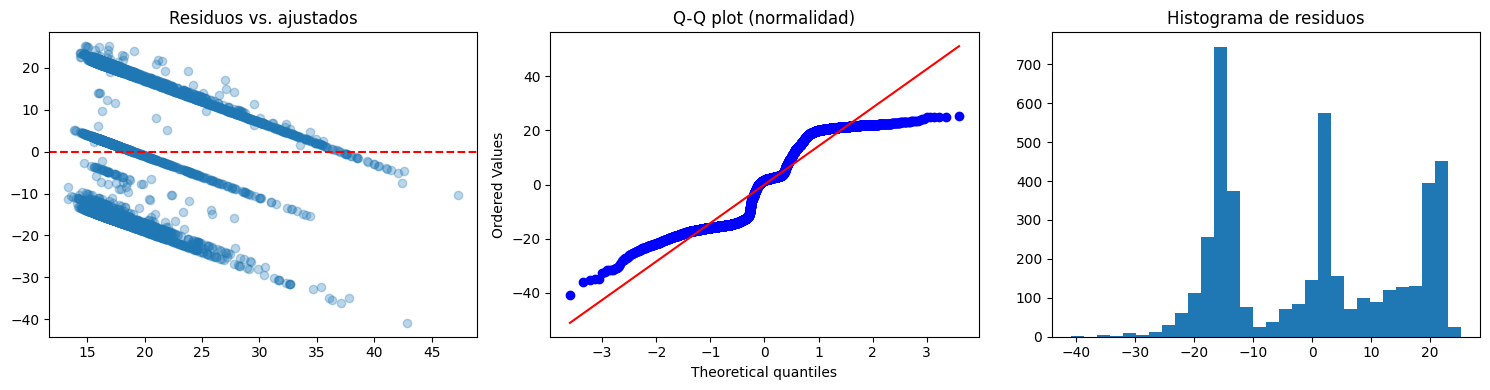

Shapiro-Wilk p-valor: 6.4536423895740505e-46


In [8]:
# Diagnóstico de supuestos
residuos = modelo_madre_qual.resid
fitted = modelo_madre_qual.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted, residuos, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos vs. ajustados')

stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot (normalidad)')

axes[2].hist(residuos, bins=30)
axes[2].set_title('Histograma de residuos')
plt.tight_layout()
plt.savefig('diagnostico_imputacion_mother_qualification.png', dpi=100)
plt.show()

print("Shapiro-Wilk p-valor:", stats.shapiro(residuos.sample(min(5000, len(residuos)), random_state=RANDOM_SEED))[1])

**Limitación metodológica reconocida:** los residuos muestran bandas diagonales paralelas y el histograma es multimodal (no campana), consecuencia esperada de usar regresión OLS sobre una variable que es, en su naturaleza, un **código categórico nominal** (niveles educativos sin distancia real entre categorías) y no una escala continua. Shapiro-Wilk confirma no-normalidad (p≈0), pero se documenta como limitación reconocida y no como error del proceso: el enunciado exige explícitamente este método para variables numéricas, y el dataset codifica estas variables como numéricas.

### 1.5 Aplicación de la imputación: redondeo al código válido más cercano

Dado que `Mother's qualification` es un código categórico discreto, las predicciones continuas del modelo se redondean al **código válido más cercano** dentro del catálogo real de valores observados (no al entero más cercano sin más, que podría caer en un código inexistente).

In [9]:
def redondear_a_codigo_valido(valor_continuo, catalogo):
    """Encuentra el código válido más cercano al valor continuo predicho."""
    catalogo_arr = np.array(catalogo)
    idx_mas_cercano = np.argmin(np.abs(catalogo_arr - valor_continuo))
    return catalogo_arr[idx_mas_cercano]

mask_imputar = df_num["Mother's qualification"].isna() & df_num[predictoras_v2].notna().all(axis=1)
print(f"Filas a imputar por regresión: {mask_imputar.sum()}")

X_imputar = sm.add_constant(df_num.loc[mask_imputar, predictoras_v2], has_constant='add')
predicciones = modelo_madre_qual.predict(X_imputar)

codigos_validos = sorted(df["Mother's qualification"].dropna().unique())
codigos_validos = [c for c in codigos_validos if c != 34]
predicciones_redondeadas = predicciones.apply(lambda v: redondear_a_codigo_valido(v, codigos_validos))

df_num["Mother's qualification_imputada"] = df_num["Mother's qualification"].copy()
df_num.loc[mask_imputar, "Mother's qualification_imputada"] = predicciones_redondeadas

print("\nDistribución de códigos imputados vía regresión:")
print(predicciones_redondeadas.value_counts().sort_index())

Filas a imputar por regresión: 116

Distribución de códigos imputados vía regresión:
14    10
18    23
19    14
22    35
26     9
27     5
29     3
30     5
35     8
36     1
38     2
39     1
Name: count, dtype: int64


In [10]:
# Casos residuales (target y alguna predictora faltante simultáneamente): imputación por moda global
faltantes_residuales = df_num["Mother's qualification_imputada"].isna()
moda_global_madre = df["Mother's qualification"][df["Mother's qualification"] != 34].mode()[0]
print(f"Moda global (excluyendo 'Unknown'): código {moda_global_madre}")
print(f"Casos residuales imputados con moda: {faltantes_residuales.sum()}")

df_num.loc[faltantes_residuales, "Mother's qualification_imputada"] = moda_global_madre
print("Valores sin imputar restantes:", df_num["Mother's qualification_imputada"].isna().sum())

Moda global (excluyendo 'Unknown'): código 1
Casos residuales imputados con moda: 14
Valores sin imputar restantes: 0


**Hallazgo relevante para el análisis comparativo (Parte 3):** los valores imputados por regresión se concentran en códigos 14-39, y **ninguno cae en las categorías más frecuentes de la población real** (código 1 = "Secundaria", 24,9%; código 3 = "Educación superior", 10,2%). Esto ocurre porque, con edad mínima de 17 años, el valor mínimo que el modelo puede predecir estructuralmente ronda ~20; la imputación por regresión sistemáticamente **distorsiona la distribución hacia categorías intermedias**, subrepresentando la categoría más común de la población. Este es un hallazgo cuantificable, no un defecto oculto.

### 1.6 Imputación de Father's qualification, Mother's occupation y Father's occupation

Se aplica la misma metodología de forma encadenada: las variables ya imputadas se usan como predictoras de los pasos siguientes (manteniendo el vínculo temático educación↔ocupación sin perder cobertura por solapamiento de faltantes).

In [11]:
def imputar_por_regresion(df_num, df_original, target, predictoras, codigo_excluir):
    train = df_num[[target] + predictoras].dropna()
    X = sm.add_constant(train[predictoras])
    y = train[target]
    modelo = sm.OLS(y, X).fit()

    vif = pd.DataFrame({
        "variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

    mask_imputar = df_num[target].isna() & df_num[predictoras].notna().all(axis=1)
    X_pred = sm.add_constant(df_num.loc[mask_imputar, predictoras], has_constant='add')
    predicciones = modelo.predict(X_pred)

    codigos_validos = sorted(df_original[target].dropna().unique())
    codigos_validos = [c for c in codigos_validos if c != codigo_excluir]
    predicciones_redondeadas = predicciones.apply(lambda v: redondear_a_codigo_valido(v, codigos_validos))

    col_imputada = f"{target}_imputada"
    df_num[col_imputada] = df_num[target].copy()
    df_num.loc[mask_imputar, col_imputada] = predicciones_redondeadas

    faltantes_residuales = df_num[col_imputada].isna()
    moda = df_original[target][df_original[target] != codigo_excluir].mode()[0]
    df_num.loc[faltantes_residuales, col_imputada] = moda

    print(f"=== {target} ===")
    print(f"R²={modelo.rsquared:.3f} | Cobertura regresión: {mask_imputar.sum()} | Moda residual: {faltantes_residuales.sum()}")
    print(vif)
    print(modelo.params)
    print()

    return df_num, modelo, vif

df_num, modelo_padre_qual, vif_padre_qual = imputar_por_regresion(
    df_num, df, "Father's qualification",
    ["Age at enrollment", "Admission grade", "Father's occupation"],
    codigo_excluir=34
)

df_num, modelo_madre_ocup, vif_madre_ocup = imputar_por_regresion(
    df_num, df, "Mother's occupation",
    ["Age at enrollment", "Admission grade", "Mother's qualification_imputada"],
    codigo_excluir=99
)

df_num, modelo_padre_ocup, vif_padre_ocup = imputar_por_regresion(
    df_num, df, "Father's occupation",
    ["Age at enrollment", "Admission grade", "Father's qualification_imputada"],
    codigo_excluir=99
)

=== Father's qualification ===
R²=0.037 | Cobertura regresión: 97 | Moda residual: 15
              variable        VIF
0                const  89.244069
1    Age at enrollment   1.000690
2      Admission grade   1.000902
3  Father's occupation   1.001315
const                  18.425003
Age at enrollment       0.372653
Admission grade        -0.042480
Father's occupation     0.032557
dtype: float64

=== Mother's occupation ===
R²=0.007 | Cobertura regresión: 17 | Moda residual: 0
                          variable        VIF
0                            const  89.515067
1                Age at enrollment   1.094244
2                  Admission grade   1.002624
3  Mother's qualification_imputada   1.096165
const                              12.589238
Age at enrollment                   0.106695
Admission grade                    -0.050563
Mother's qualification_imputada     0.102812
dtype: float64

=== Father's occupation ===
R²=0.004 | Cobertura regresión: 19 | Moda residual: 0
      

### 1.7 Resumen de la imputación

| Variable | Faltantes totales | Vía regresión | Vía moda | R² del modelo |
|---|---|---|---|---|
| Mother's qualification | 130 | 116 | 14 | 0,086 |
| Father's qualification | 112 | 97 | 15 | 0,037 |
| Mother's occupation | 17 | 17 | 0 | 0,007 |
| Father's occupation | 19 | 19 | 0 | 0,004 |

VIF ≈1 en todas las predictoras de los cuatro modelos, sin colinealidad. Los R² de las variables de ocupación son muy bajos (≈0), un hallazgo honesto a documentar: los códigos de ocupación (clasificación tipo ISCO, no ordinal) no son bien explicados por edad, nota de admisión ni nivel educativo del progenitor. El impacto práctico es acotado dado el bajo número de casos afectados (17 y 19).

**Pendiente:** Parte 2 (regresión logística), Parte 3 (comparación de estrategias de imputación), Parte 4 (informe integrado), Parte 5 (presentación).

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

## Parte 2 — Clasificación mediante regresión logística

### 2.1 Preparación de datos informada por S1

Se mantiene el encuadre Dropout vs. No-Dropout con las 4.424 filas completas, siguiendo la indicación del docente en su retroalimentación de la Sumativa 2, para preservar la trazabilidad S1 → S2 → S3. No se excluyen las observaciones de edad sobre el percentil 99 (43 casos): aunque S2 mostró que su exclusión fortalece el test de Welch, el propio análisis de robustez de S2 ya demostró que el hallazgo se sostiene con o sin esas observaciones, y el docente solicitó mantener las 4.424 filas completas.

Las variables numéricas se mantienen en su escala original (sin estandarizar) para preservar la interpretabilidad directa de los odds ratios en unidades de negocio.

In [13]:
# Target binario: Dropout=1, No-Dropout (Enrolled+Graduate)=0
df_num['Target_binario'] = (df['Target'] == 'Dropout').astype(int)
print(df_num['Target_binario'].value_counts(normalize=True))

Target_binario
0    0.678797
1    0.321203
Name: proportion, dtype: float64


In [14]:
candidatas_m1 = ["Age at enrollment", "Admission grade",
                 "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
                 "Tuition fees up to date"]

X_full = df_num[candidatas_m1].copy()
y_full = df_num['Target_binario'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.30, random_state=RANDOM_SEED, stratify=y_full
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporción Dropout en train:", y_train.mean(), "| en test:", y_test.mean())

Train: (3096, 5) | Test: (1328, 5)
Proporción Dropout en train: 0.3210594315245478 | en test: 0.32153614457831325


### 2.2 Selección de variables informada por S1 y S2

Antes de decidir entre `approved` y `grade` (r=0,761 en S1), se evalúa su colinealidad mediante VIF, tal como solicitó el docente en su retroalimentación de S2.

In [15]:
X_check = sm.add_constant(X_train)
vif_m1 = pd.DataFrame({
    "variable": X_check.columns,
    "VIF": [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
})
print(vif_m1)

                              variable        VIF
0                                const  99.009159
1                    Age at enrollment   1.051793
2                      Admission grade   1.003395
3  Curricular units 2nd sem (approved)   2.403736
4     Curricular units 2nd sem (grade)   2.425372
5              Tuition fees up to date   1.135446


VIF de `approved`/`grade` (2,40 y 2,43) queda por debajo del umbral convencional de severidad (5 o 10), pero se mantiene la decisión de retener solo una, siguiendo la indicación explícita del docente sobre su redundancia conceptual. Se decide entre ambas comparando su correlación con el Target.

In [16]:
print("Correlación con Target_binario:")
print("approved:", df_num["Curricular units 2nd sem (approved)"].corr(df_num["Target_binario"]))
print("grade:", df_num["Curricular units 2nd sem (grade)"].corr(df_num["Target_binario"]))

Correlación con Target_binario:
approved: -0.5695002441277314
grade: -0.5717922029440704


Con correlación casi idéntica (r=-0,5695 vs. r=-0,5718), la decisión se resuelve por interpretabilidad de negocio: `approved` (conteo de asignaturas) permite un odds ratio directamente accionable, mientras `grade` (promedio continuo) es más abstracto. Se retiene `Curricular units 2nd sem (approved)` para el Modelo 1.

**Modelo 1: basado en correlaciones de S1/S2:**

In [17]:
predictoras_m1_final = ["Age at enrollment", "Admission grade",
                         "Curricular units 2nd sem (approved)", "Tuition fees up to date"]

X_train_m1 = sm.add_constant(X_train[predictoras_m1_final])
X_test_m1 = sm.add_constant(X_test[predictoras_m1_final], has_constant='add')

modelo_1 = sm.Logit(y_train, X_train_m1).fit()
print(modelo_1.summary())

odds_ratios_m1 = np.exp(modelo_1.params)
print("\nOdds ratios:")
print(odds_ratios_m1)

Optimization terminated successfully.
         Current function value: 0.366021
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         Target_binario   No. Observations:                 3096
Model:                          Logit   Df Residuals:                     3091
Method:                           MLE   Df Model:                            4
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.4169
Time:                        09:16:46   Log-Likelihood:                -1133.2
converged:                       True   LL-Null:                       -1943.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   3.8534      0.527 

**Modelo 2: selección stepwise bidireccional** (criterio de p-valor: entrada 0,05 / salida 0,10), sobre un pool de 9 candidatas que incluye las 4 variables de padres imputadas en la Parte 1.

In [18]:
def stepwise_logit(df, target, candidatas, p_entrada=0.05, p_salida=0.10, verbose=True):
    """Selección stepwise bidireccional basada en p-valor."""
    incluidas = []
    while True:
        cambio = False
        excluidas = [v for v in candidatas if v not in incluidas]
        mejor_pval = 1.0
        mejor_var = None
        for var in excluidas:
            vars_prueba = incluidas + [var]
            X = sm.add_constant(df[vars_prueba])
            modelo = sm.Logit(df[target], X).fit(disp=0)
            pval = modelo.pvalues[var]
            if pval < mejor_pval:
                mejor_pval = pval
                mejor_var = var
        if mejor_var is not None and mejor_pval < p_entrada:
            incluidas.append(mejor_var)
            cambio = True
            if verbose:
                print(f"+ Agregada: {mejor_var} (p={mejor_pval:.4f})")

        if incluidas:
            X = sm.add_constant(df[incluidas])
            modelo = sm.Logit(df[target], X).fit(disp=0)
            pvals = modelo.pvalues.drop('const')
            peor_pval = pvals.max()
            peor_var = pvals.idxmax()
            if peor_pval > p_salida:
                incluidas.remove(peor_var)
                cambio = True
                if verbose:
                    print(f"- Eliminada: {peor_var} (p={peor_pval:.4f})")

        if not cambio:
            break
    return incluidas

candidatas_pool = ["Age at enrollment", "Admission grade",
                    "Curricular units 2nd sem (approved)", "Tuition fees up to date",
                    "Unemployment rate",
                    "Mother's qualification_imputada", "Father's qualification_imputada",
                    "Mother's occupation_imputada", "Father's occupation_imputada"]

train_completo = df_num.loc[X_train.index]
train_completo['Target_binario'] = y_train

variables_m2 = stepwise_logit(train_completo, 'Target_binario', candidatas_pool)
print("\nVariables seleccionadas por stepwise:", variables_m2)

X_train_m2 = sm.add_constant(train_completo[variables_m2])
modelo_2 = sm.Logit(train_completo['Target_binario'], X_train_m2).fit()
print(modelo_2.summary())
print("\nOdds ratios:")
print(np.exp(modelo_2.params))

+ Agregada: Curricular units 2nd sem (approved) (p=0.0000)
+ Agregada: Tuition fees up to date (p=0.0000)
+ Agregada: Age at enrollment (p=0.0000)
+ Agregada: Admission grade (p=0.0002)
+ Agregada: Father's occupation_imputada (p=0.0016)
+ Agregada: Unemployment rate (p=0.0379)

Variables seleccionadas por stepwise: ['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Age at enrollment', 'Admission grade', "Father's occupation_imputada", 'Unemployment rate']
Optimization terminated successfully.
         Current function value: 0.363429
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         Target_binario   No. Observations:                 3096
Model:                          Logit   Df Residuals:                     3089
Method:                           MLE   Df Model:                            6
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.4210
Time:                    

**Hallazgo relevante:** el stepwise seleccionó `Father's occupation_imputada` (p=0,003) sin que se le indicara explícitamente, lo que confirma que la decisión de incluir las variables de padres imputadas en la Parte 1 como candidatas fue acertada, y resuelve de forma natural el requisito de la Parte 3 (el modelo final depende de una imputación).

**Modelo 3: selección por criterios de información (AIC/BIC):**

In [19]:
def mejor_modelo_por_criterio(df, target, candidatas, criterio='aic', max_vars=None):
    """Búsqueda forward greedy minimizando AIC o BIC."""
    incluidas = []
    mejor_valor = np.inf
    max_vars = max_vars or len(candidatas)

    while len(incluidas) < max_vars:
        candidatas_restantes = [v for v in candidatas if v not in incluidas]
        mejor_var_ronda = None
        mejor_valor_ronda = mejor_valor

        for var in candidatas_restantes:
            vars_prueba = incluidas + [var]
            X = sm.add_constant(df[vars_prueba])
            modelo = sm.Logit(df[target], X).fit(disp=0)
            valor = modelo.aic if criterio == 'aic' else modelo.bic
            if valor < mejor_valor_ronda:
                mejor_valor_ronda = valor
                mejor_var_ronda = var

        if mejor_var_ronda is None:
            break
        incluidas.append(mejor_var_ronda)
        mejor_valor = mejor_valor_ronda
        print(f"+ {mejor_var_ronda} | {criterio.upper()}={mejor_valor:.2f}")

    return incluidas

print("=== Búsqueda por AIC ===")
variables_m3_aic = mejor_modelo_por_criterio(train_completo, 'Target_binario', candidatas_pool, criterio='aic')

print("\n=== Búsqueda por BIC ===")
variables_m3_bic = mejor_modelo_por_criterio(train_completo, 'Target_binario', candidatas_pool, criterio='bic')

print("\nVariables por AIC:", variables_m3_aic)
print("Variables por BIC:", variables_m3_bic)

=== Búsqueda por AIC ===
+ Curricular units 2nd sem (approved) | AIC=2621.44
+ Tuition fees up to date | AIC=2364.45
+ Age at enrollment | AIC=2288.83
+ Admission grade | AIC=2276.40
+ Father's occupation_imputada | AIC=2266.67
+ Unemployment rate | AIC=2264.35

=== Búsqueda por BIC ===
+ Curricular units 2nd sem (approved) | BIC=2633.51
+ Tuition fees up to date | BIC=2382.56
+ Age at enrollment | BIC=2312.98
+ Admission grade | BIC=2306.59
+ Father's occupation_imputada | BIC=2302.90

Variables por AIC: ['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Age at enrollment', 'Admission grade', "Father's occupation_imputada", 'Unemployment rate']
Variables por BIC: ['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Age at enrollment', 'Admission grade', "Father's occupation_imputada"]


AIC convergió exactamente con el stepwise (6 variables). BIC, más conservador, penaliza cada variable adicional ~4 veces más fuerte que AIC con este tamaño de muestra, y se detuvo antes, descartando `Unemployment rate` (la variable más marginal). Se adopta el **set de BIC (5 variables)** como Modelo 3, para que los tres modelos queden genuinamente diferenciados.

In [20]:
variables_m3 = ['Curricular units 2nd sem (approved)', 'Tuition fees up to date',
                'Age at enrollment', 'Admission grade', "Father's occupation_imputada"]

X_train_m3 = sm.add_constant(train_completo[variables_m3])
modelo_3 = sm.Logit(train_completo['Target_binario'], X_train_m3).fit()
print(modelo_3.summary())

print("\nOdds ratios:")
print(np.exp(modelo_3.params))

Optimization terminated successfully.
         Current function value: 0.364127
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         Target_binario   No. Observations:                 3096
Model:                          Logit   Df Residuals:                     3090
Method:                           MLE   Df Model:                            5
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.4199
Time:                        09:16:47   Log-Likelihood:                -1127.3
converged:                       True   LL-Null:                       -1943.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   3.9695      0.531 

### 2.3 Evaluación de estabilidad mediante bootstrap

Se aplica bootstrap (10.000 remuestras, semilla 123456) al Modelo 1 (elegido como final en 2.5), construyendo IC 95% para coeficientes y odds ratios, y comparándolos con los IC tradicionales (Wald).

In [21]:
n_bootstrap = 10000
coefs_boot = np.zeros((n_bootstrap, len(predictoras_m1_final) + 1))

train_boot_base = train_completo[predictoras_m1_final + ['Target_binario']].reset_index(drop=True)
rng = np.random.default_rng(RANDOM_SEED)

for i in range(n_bootstrap):
    idx = rng.choice(len(train_boot_base), size=len(train_boot_base), replace=True)
    muestra = train_boot_base.iloc[idx]
    X_boot = sm.add_constant(muestra[predictoras_m1_final], has_constant='add')
    y_boot = muestra['Target_binario']
    try:
        modelo_boot = sm.Logit(y_boot, X_boot).fit(disp=0)
        coefs_boot[i, :] = modelo_boot.params.values
    except Exception:
        coefs_boot[i, :] = np.nan

coefs_boot_df = pd.DataFrame(coefs_boot, columns=['const'] + predictoras_m1_final)
print("Filas con error de convergencia (descartadas):", coefs_boot_df.isna().any(axis=1).sum())
coefs_boot_df = coefs_boot_df.dropna()

ic_boot = coefs_boot_df.quantile([0.025, 0.975]).T
ic_boot.columns = ['IC_2.5%', 'IC_97.5%']
ic_boot['coef_original'] = modelo_1.params.values
print(ic_boot)

ic_boot_or = np.exp(ic_boot[['IC_2.5%', 'IC_97.5%', 'coef_original']])
print("\nOdds ratios con IC bootstrap:")
print(ic_boot_or)

Filas con error de convergencia (descartadas): 0
                                      IC_2.5%  IC_97.5%  coef_original
const                                2.891196  4.849613       3.853407
Age at enrollment                    0.047984  0.074015       0.060432
Admission grade                     -0.020328 -0.006674      -0.013581
Curricular units 2nd sem (approved) -0.622558 -0.518143      -0.567778
Tuition fees up to date             -2.899811 -2.142022      -2.490752

Odds ratios con IC bootstrap:
                                       IC_2.5%    IC_97.5%  coef_original
const                                18.014835  127.690959      47.153446
Age at enrollment                     1.049154    1.076823       1.062295
Admission grade                       0.979877    0.993348       0.986511
Curricular units 2nd sem (approved)   0.536570    0.595626       0.566783
Tuition fees up to date               0.055034    0.117417       0.082848


**Resultado:** 0 errores de convergencia en 10.000 iteraciones. Ningún IC (ni de coeficiente ni de odds ratio) cruza el valor nulo; los 4 parámetros del Modelo 1 son estables. Los IC bootstrap coinciden con los tradicionales (Wald), confirmando que la aproximación asintótica es confiable para este tamaño muestral (n=3.096), mismo patrón observado en S2.

### 2.4 Diagnóstico de supuestos

**Multicolinealidad (VIF):** ver 2.2, sin colinealidad severa (todas <2,5).

**Linealidad en el logit (test de Box-Tidwell):**

In [22]:
df_bt = train_completo[predictoras_m1_final + ['Target_binario']].copy()

for var in ["Age at enrollment", "Admission grade"]:
    df_bt[f"{var}_log_interaccion"] = df_bt[var] * np.log(df_bt[var])

vars_bt = predictoras_m1_final + ["Age at enrollment_log_interaccion", "Admission grade_log_interaccion"]
X_bt = sm.add_constant(df_bt[vars_bt])
modelo_bt = sm.Logit(df_bt['Target_binario'], X_bt).fit(disp=0)
print("Test de Box-Tidwell (linealidad en el logit):")
print(modelo_bt.summary().tables[1])
print("\nSi el término de interacción NO es significativo (p>0.05), se cumple linealidad en el logit.")

Test de Box-Tidwell (linealidad en el logit):
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                 -16.6514      6.034     -2.760      0.006     -28.477      -4.826
Age at enrollment                       1.0138      0.194      5.217      0.000       0.633       1.395
Admission grade                         0.6337      0.262      2.415      0.016       0.119       1.148
Curricular units 2nd sem (approved)    -0.5658      0.023    -24.817      0.000      -0.611      -0.521
Tuition fees up to date                -2.4823      0.189    -13.120      0.000      -2.853      -2.112
Age at enrollment_log_interaccion      -0.2157      0.044     -4.893      0.000      -0.302      -0.129
Admission grade_log_interaccion        -0.1102      0.045     -2.462      0.014      -0.198      -0.022

Si el término de 

**Resultado:** ambos términos de interacción son significativos (Age p<0,001; Admission grade p=0,014), por lo que no se cumple linealidad en el logit para ninguna de las dos variables continuas. Se documenta como limitación reconocida, sin corregir con términos cuadráticos o splines por restricción de tiempo.

**Observaciones influyentes (distancia de Cook):**

Umbral de Cook (4/n): 0.00129
Observaciones influyentes: 208 de 3096 (6.7%)


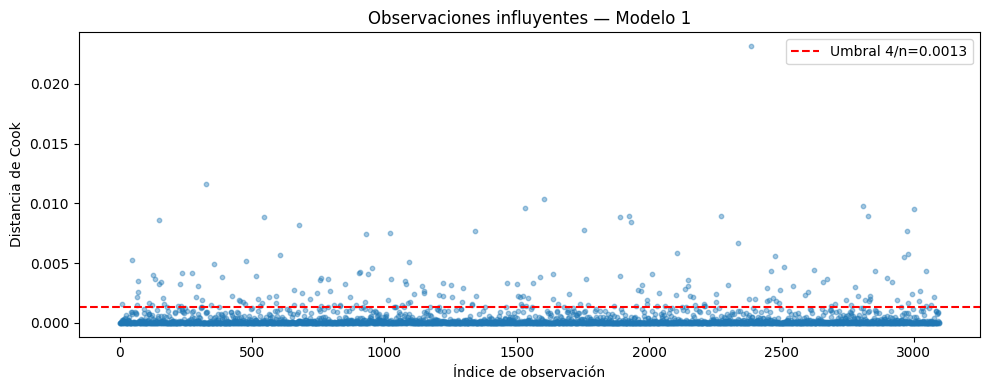

In [23]:
influencia = modelo_1.get_influence()
cooks_d = influencia.cooks_distance[0]

umbral_cook = 4 / len(train_completo)
influyentes = np.where(cooks_d > umbral_cook)[0]
print(f"Umbral de Cook (4/n): {umbral_cook:.5f}")
print(f"Observaciones influyentes: {len(influyentes)} de {len(train_completo)} ({len(influyentes)/len(train_completo)*100:.1f}%)")

plt.figure(figsize=(10, 4))
plt.scatter(range(len(cooks_d)), cooks_d, alpha=0.4, s=10)
plt.axhline(umbral_cook, color='red', linestyle='--', label=f'Umbral 4/n={umbral_cook:.4f}')
plt.xlabel("Índice de observación")
plt.ylabel("Distancia de Cook")
plt.title("Observaciones influyentes — Modelo 1")
plt.legend()
plt.tight_layout()
plt.savefig('influencia_modelo1.png', dpi=100)
plt.show()

**Resultado:** 208 de 3.096 observaciones (6,7%) superan el umbral convencional 4/n, umbral muy conservador para muestras grandes. Se identifica una observación individual claramente atípica (distancia ≈0,023) que merece revisión puntual.

**Residuos de deviance** (calculados manualmente: `MLEInfluence` no expone `resid_dev` para modelos Logit):

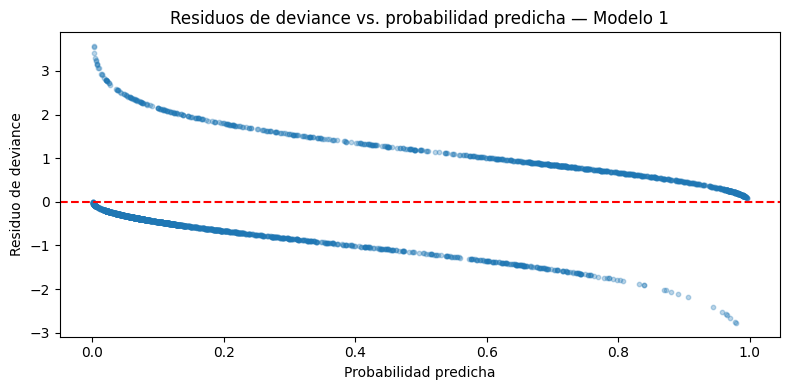

In [24]:
p_hat = modelo_1.predict(X_train_m1)
y_real = train_completo['Target_binario'].values

residuos_deviance = np.sign(y_real - p_hat) * np.sqrt(
    -2 * (y_real * np.log(p_hat) + (1 - y_real) * np.log(1 - p_hat))
)

plt.figure(figsize=(8, 4))
plt.scatter(p_hat, residuos_deviance, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Residuo de deviance")
plt.title("Residuos de deviance vs. probabilidad predicha — Modelo 1")
plt.tight_layout()
plt.savefig('residuos_modelo1.png', dpi=100)
plt.show()

**Resultado:** el patrón de dos bandas curvas es normal y esperado en clasificación binaria (una banda para Dropout=1, otra para Dropout=0), lo que no es evidencia de mala especificación.

### 2.5 Evaluación de desempeño predictivo

In [25]:
def evaluar_modelo(modelo, X_train_m, X_test_m, y_train_e, y_test_e, nombre, umbral=0.5):
    pred_train_prob = modelo.predict(X_train_m)
    pred_test_prob = modelo.predict(X_test_m)

    pred_train = (pred_train_prob >= umbral).astype(int)
    pred_test = (pred_test_prob >= umbral).astype(int)

    print(f"\n=== {nombre} ===")
    print("Matriz de confusión (train):")
    print(confusion_matrix(y_train_e, pred_train))
    print("Matriz de confusión (test):")
    print(confusion_matrix(y_test_e, pred_test))

    print(f"\nMétricas en TEST:")
    print(f"Accuracy:  {accuracy_score(y_test_e, pred_test):.4f}")
    print(f"Precision: {precision_score(y_test_e, pred_test):.4f}")
    print(f"Recall:    {recall_score(y_test_e, pred_test):.4f}")
    print(f"F1-score:  {f1_score(y_test_e, pred_test):.4f}")

    auc = roc_auc_score(y_test_e, pred_test_prob)
    print(f"AUC:       {auc:.4f}")

    return pred_test_prob, auc

test_completo = df_num.loc[X_test.index]

X_test_m1 = sm.add_constant(test_completo[predictoras_m1_final], has_constant='add')
X_test_m2 = sm.add_constant(test_completo[variables_m2], has_constant='add')
X_test_m3 = sm.add_constant(test_completo[variables_m3], has_constant='add')

probs_m1, auc_m1 = evaluar_modelo(modelo_1, X_train_m1, X_test_m1, y_train, y_test, "Modelo 1 (S1/S2)")
probs_m2, auc_m2 = evaluar_modelo(modelo_2, X_train_m2, X_test_m2, train_completo['Target_binario'], y_test, "Modelo 2 (Stepwise)")
probs_m3, auc_m3 = evaluar_modelo(modelo_3, X_train_m3, X_test_m3, train_completo['Target_binario'], y_test, "Modelo 3 (BIC)")


=== Modelo 1 (S1/S2) ===
Matriz de confusión (train):
[[1917  185]
 [ 272  722]]
Matriz de confusión (test):
[[832  69]
 [130 297]]

Métricas en TEST:
Accuracy:  0.8502
Precision: 0.8115
Recall:    0.6956
F1-score:  0.7491
AUC:       0.8723

=== Modelo 2 (Stepwise) ===
Matriz de confusión (train):
[[1921  181]
 [ 262  732]]
Matriz de confusión (test):
[[834  67]
 [134 293]]

Métricas en TEST:
Accuracy:  0.8486
Precision: 0.8139
Recall:    0.6862
F1-score:  0.7446
AUC:       0.8740

=== Modelo 3 (BIC) ===
Matriz de confusión (train):
[[1919  183]
 [ 267  727]]
Matriz de confusión (test):
[[834  67]
 [133 294]]

Métricas en TEST:
Accuracy:  0.8494
Precision: 0.8144
Recall:    0.6885
F1-score:  0.7462
AUC:       0.8729


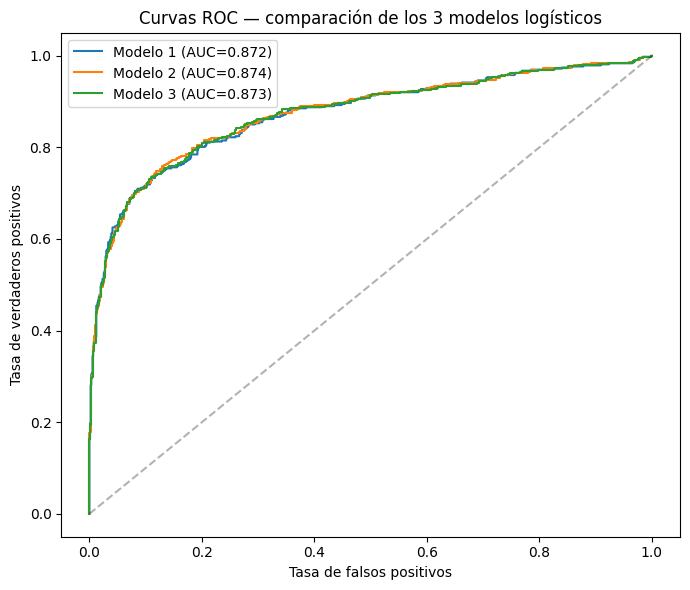

In [26]:
plt.figure(figsize=(7, 6))
for probs, auc, nombre in [(probs_m1, auc_m1, "Modelo 1"), (probs_m2, auc_m2, "Modelo 2"), (probs_m3, auc_m3, "Modelo 3")]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC — comparación de los 3 modelos logísticos")
plt.legend()
plt.tight_layout()
plt.savefig('roc_comparacion_3_modelos.png', dpi=100)
plt.show()

**Modelo final seleccionado: Modelo 1.** Justificación: (a) igual o mejor desempeño que los modelos más complejos en Accuracy, Recall y F1-score, con AUC prácticamente idéntico (diferencia de 0,0017 respecto del mejor); (b) mayor simplicidad (4 variables vs. 6), evidenciado en que agregar variables mejoró el ajuste en entrenamiento sin mejora correspondiente en test, condición característica de empezar a sobreajustar; (c) máxima interpretabilidad de negocio; (d) coherencia directa con S1/S2.

## Parte 3 — Análisis comparativo del impacto de la imputación

Como el Modelo 1 (elegido como final) no incluye variables imputadas, se utiliza el **Modelo 3 (BIC)**, que sí incorpora `Father's occupation_imputada`, para que la comparación de estrategias tenga impacto real sobre un modelo de clasificación.

In [27]:
mask_completo = df["Father's occupation"] != 99
df_elim = df_num.loc[mask_completo].copy()

moda_padre_ocup = df.loc[df["Father's occupation"] != 99, "Father's occupation"].mode()[0]
df_simple = df_num.copy()
df_simple["Father's occupation_v2"] = df["Father's occupation"].replace(99, moda_padre_ocup)

df_regresion = df_num.copy()  # usa Father's occupation_imputada

variables_m3_base = ['Curricular units 2nd sem (approved)', 'Tuition fees up to date',
                      'Age at enrollment', 'Admission grade']

resultados_comparacion = []

for nombre, dataset, col_ocup in [
    ("Eliminación", df_elim, "Father's occupation"),
    ("Imputación simple", df_simple, "Father's occupation_v2"),
    ("Imputación regresión", df_regresion, "Father's occupation_imputada")
]:
    vars_modelo = variables_m3_base + [col_ocup]
    X_tr, X_te, y_tr, y_te = train_test_split(
        dataset[vars_modelo], dataset['Target_binario'],
        test_size=0.30, random_state=RANDOM_SEED, stratify=dataset['Target_binario']
    )
    X_tr_c = sm.add_constant(X_tr)
    X_te_c = sm.add_constant(X_te, has_constant='add')
    modelo_temp = sm.Logit(y_tr, X_tr_c).fit(disp=0)

    probs_te = modelo_temp.predict(X_te_c)
    pred_te = (probs_te >= 0.5).astype(int)

    resultados_comparacion.append({
        "Estrategia": nombre,
        "N muestral": len(dataset),
        f"Coef {col_ocup.replace('_v2','').replace('_imputada','')}": modelo_temp.params[col_ocup],
        "IC 2.5%": modelo_temp.conf_int().loc[col_ocup, 0],
        "IC 97.5%": modelo_temp.conf_int().loc[col_ocup, 1],
        "AUC": roc_auc_score(y_te, probs_te),
        "Accuracy": accuracy_score(y_te, pred_te)
    })

comparacion_df = pd.DataFrame(resultados_comparacion)
print(comparacion_df.to_string(index=False))

          Estrategia  N muestral  Coef Father's occupation   IC 2.5%  IC 97.5%      AUC  Accuracy
         Eliminación        4405                 -0.006386 -0.011463 -0.001310 0.887067  0.860061
   Imputación simple        4424                 -0.008294 -0.013447 -0.003141 0.872938  0.849398
Imputación regresión        4424                 -0.008297 -0.013451 -0.003144 0.872936  0.849398


**Conclusión:** el coeficiente y el AUC son prácticamente idénticos entre imputación simple y por regresión (diferencia de milésimas), con solo 19 de 4.424 filas afectadas (0,43%). El AUC ligeramente mayor de la Eliminación refleja el azar de muestreo al evaluar sobre un conjunto de test distinto, no un mérito real del método. Con un porcentaje de faltantes tan bajo, la estrategia de tratamiento de datos faltantes no modifica de forma sustantiva ninguna conclusión del modelo. Se recomienda igualmente la imputación por regresión sobre la eliminación por un principio metodológico (preservar el tamaño muestral y evitar el sesgo potencial de eliminar sistemáticamente casos con patrón MAR).

## Cierre

Con esto se completan las Partes 1, 2 y 3 del enunciado (manejo de faltantes, clasificación mediante regresión logística, y análisis comparativo del impacto de la imputación). El informe integrado (Parte 4) y la presentación (Parte 5) se desarrollan como entregables separados, sintetizando estos resultados junto con los de S1 y S2.